# <font size=7> 10장 포트폴리오 이론</font>

### 코드 10-1 베타 계수 계산1

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import yfinance as yf
import matplotlib.pyplot as plt

stock_tickers = ['AAPL', 'TSLA', 'KO', 'JNJ']
market_ticker = ['SPY']
tickers = stock_tickers + market_ticker

stocks = yf.download(tickers, '2019-01-01', '2021-01-01', multi_level_index=False, auto_adjust=False)['Adj Close']
returns = stocks.pct_change().dropna()
covariance = returns.cov()

print('=== Beta of Stocks ===')
for ticker in stock_tickers:
    beta = covariance.loc[ticker,'SPY']/returns['SPY'].var()
    print(f'{ticker}: {beta:.4f}')

[*********************100%%**********************]  5 of 5 completed


=== Beta of Stocks ===
AAPL: 1.2058
TSLA: 1.2813
KO: 0.7878
JNJ: 0.6731


### 코드 10-2 베타 계수 계산2

In [3]:
X = returns['SPY']
X_const = sm.add_constant(X)
print('=== Beta of Stocks ===')
for ticker in stock_tickers:
    Y = returns[ticker]
    model = sm.OLS(Y, X_const).fit()
    beta = model.params['SPY']
    print(f'{ticker}: {beta:.4f}')

=== Beta of Stocks ===
AAPL: 1.2058
TSLA: 1.2813
KO: 0.7878
JNJ: 0.6731


### 그림 10-1 주식 누적 수익률 그래프

In [4]:
stocks = yf.download(tickers, '2021-01-01', '2023-01-01', multi_level_index=False, auto_adjust=False)['Adj Close']

[*********************100%%**********************]  5 of 5 completed


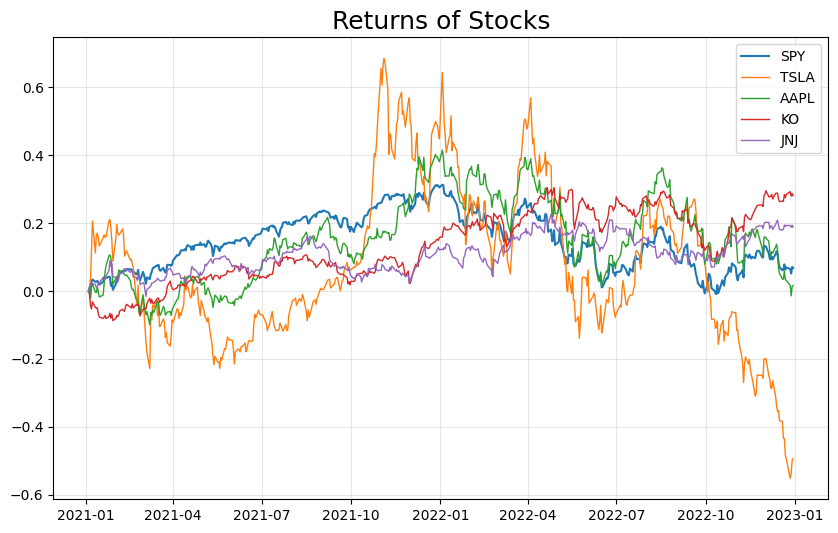

In [5]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(stocks.index, stocks['SPY']/stocks['SPY'].iloc[0]-1, label='SPY', linewidth=1.5)
ax.plot(stocks.index, stocks['TSLA']/stocks['TSLA'].iloc[0]-1, label='TSLA', linewidth=1)
ax.plot(stocks.index, stocks['AAPL']/stocks['AAPL'].iloc[0]-1, label='AAPL', linewidth=1)
ax.plot(stocks.index, stocks['KO']/stocks['KO'].iloc[0]-1, label='KO', linewidth=1)
ax.plot(stocks.index, stocks['JNJ']/stocks['JNJ'].iloc[0]-1, label='JNJ', linewidth=1)
ax.set_title('Returns of Stocks', fontsize=18)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 코드 10-3 AAPL과 SH에 대한 일간 수익률의 평균과 분산

In [6]:
stocks = yf.download(['AAPL', 'SH'], '2022-01-01', '2024-01-01', multi_level_index=False, auto_adjust=False)['Adj Close']
returns = stocks.pct_change().dropna()
stock_ret = returns.mean()
stock_vol = returns.std()

print(f'AAPL의 일간 기대 수익률: {100*stock_ret['AAPL']:.3f}%')
print(f'AAPL의 일간 위험: {stock_vol['AAPL']:.4f}')
print(f'SH의 일간 기대 수익률: {100*stock_ret['SH']:.3f}%')
print(f'SH의 일간 위험: {stock_vol['SH']:.4f}\n')

cov_matrix = returns.cov()
print('Covariance Matrix')
print(cov_matrix)

[*********************100%%**********************]  2 of 2 completed


AAPL의 일간 기대 수익률: 0.030%
AAPL의 일간 위험: 0.0183
SH의 일간 기대 수익률: 0.010%
SH의 일간 위험: 0.0123

Covariance Matrix
Ticker      AAPL        SH
Ticker                    
AAPL    0.000335 -0.000190
SH     -0.000190  0.000151


### 코드 10-4 AAPL과 SH로 구성된 포트폴리오의 일간 수익률의 평균과 분산 계산

In [7]:
num_portfolio = 5000
weight = np.zeros((num_portfolio,2)) # w1, w2
portfolio_ret = np.zeros(num_portfolio) # mu_Y
portfolio_vol = np.zeros(num_portfolio) # sigma_Y

for k in range(num_portfolio):
    w = np.random.random(2)
    w = w/np.sum(w)
    weight[k,:] = w
    portfolio_ret[k] = np.sum(w*stock_ret)
    portfolio_vol[k] = np.sqrt( np.dot(w, np.dot(cov_matrix,w)) )

min_idx = portfolio_vol.argmin()
print(f'포트폴리오 일간 최소 위험: {portfolio_vol[min_idx]:.4f}')
print(f'최소 위험 가중치: {weight[min_idx,:]}')

포트폴리오 일간 최소 위험: 0.0041
최소 위험 가중치: [0.39332709 0.60667291]


### 코드 10-5 AAPL과 SH로 구성된 포트폴리오의 일간 수익률의 평균과 표준편차 그래프 출력

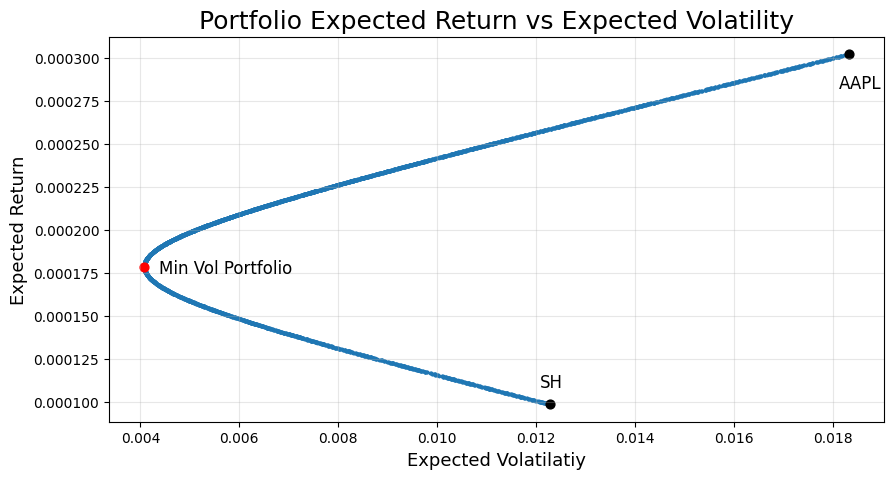

In [8]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(portfolio_vol, portfolio_ret, s=3)

ax.scatter(portfolio_vol[min_idx], portfolio_ret[min_idx], c='r', s=40)
ax.scatter(stock_vol['AAPL'], stock_ret['AAPL'], c='k', s=40)
ax.scatter(stock_vol['SH'], stock_ret['SH'], c='k', s=40)

ax.text(portfolio_vol[min_idx]+0.0003, portfolio_ret[min_idx]-0.000004, \
         'Min Vol Portfolio', fontsize=12)
ax.text(stock_vol['AAPL']-0.0002, stock_ret['AAPL']-0.00002, \
         'AAPL', fontsize=12)
ax.text(stock_vol['SH']-0.0002, stock_ret['SH']+0.00001, \
         'SH', fontsize=12)

ax.set_title('Portfolio Expected Return vs Expected Volatility', fontsize=18)
ax.set_xlabel('Expected Volatilatiy', fontsize=13)
ax.set_ylabel('Expected Return', fontsize=13)
#pset_lt.xlim(0.0,0.045)
#plt.ylim(0.0,0.0065)
ax.grid(alpha=0.3)
plt.show()

### 코드 10-6 6개 종목으로 구성된 포트폴리오의 일간 수익률의 평균과 표준편차 계산

In [9]:
tickers = ['AAPL','GE','TSLA','F','CVX','AMZN']
stocks = yf.download(tickers, '2020-01-01', '2021-07-01', multi_level_index=False, auto_adjust=False)['Adj Close']
returns = stocks.pct_change().dropna()
stock_ret = returns.mean()
stock_vol = returns.std()
cov_matrix = returns.cov()

num_portfolio = 100000
weight = np.zeros((num_portfolio,6))
portfolio_ret = np.zeros(num_portfolio)
portfolio_vol = np.zeros(num_portfolio)
sharpe_ratio = np.zeros(num_portfolio)

for k in range(num_portfolio):
    w = np.random.random(6)
    w = w/np.sum(w)
    weight[k,:] = w
    portfolio_ret[k] = np.sum(w*stock_ret)
    portfolio_vol[k] = np.sqrt( np.dot(w.T, np.dot(cov_matrix,w)) )
    sharpe_ratio[k] = portfolio_ret[k]/portfolio_vol[k]
    
min_idx = portfolio_vol.argmin()
max_idx = sharpe_ratio.argmax()

print('=== 최소 분산 포트폴리오 ===')
print(f'일간 수익률 변동성: {portfolio_vol[min_idx]:.4f}, 일간 수익률 기댓값: '\
f'{portfolio_ret[min_idx]:.4f}')
print(f'가중치: {weight[min_idx,:]}')
print('=== 최대 샤프 비율 포트폴리오 ===')
print(f'일간 수익률 변동성: {portfolio_vol[max_idx]:.4f}, 일간 수익률 기댓값: '\
f'{portfolio_ret[max_idx]:.4f}')
print(f'가중치: {weight[max_idx,:]}')

[*********************100%%**********************]  6 of 6 completed


=== 최소 분산 포트폴리오 ===
일간 수익률 변동성: 0.0189, 일간 수익률 기댓값: 0.0016
가중치: [0.0375446  0.6866379  0.10335716 0.10549502 0.06623135 0.00073396]
=== 최대 샤프 비율 포트폴리오 ===
일간 수익률 변동성: 0.0310, 일간 수익률 기댓값: 0.0042
가중치: [0.03212641 0.33009349 0.000854   0.13372595 0.0250194  0.47818076]


### 코드 10-7 6개 종목으로 구성된 포트폴리오의 일간 수익률의 평균과 표준편차 그래프 출력

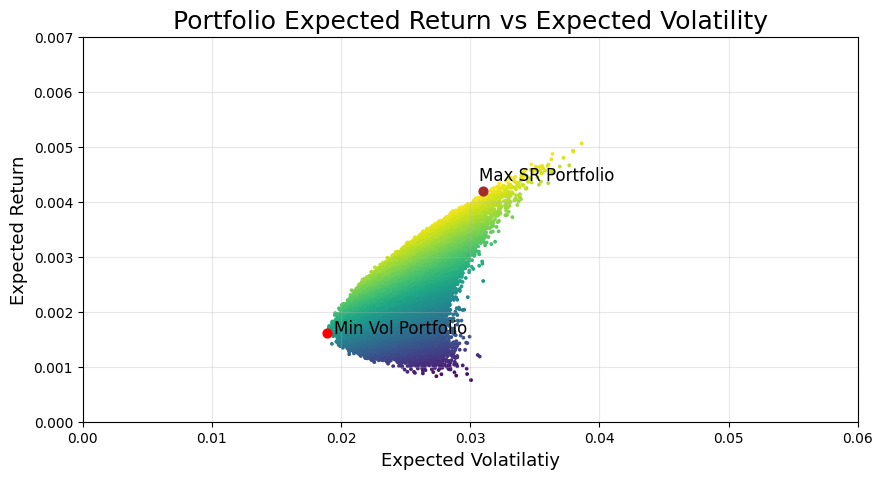

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(portfolio_vol, portfolio_ret, s=3, c=sharpe_ratio)

ax.scatter(portfolio_vol[min_idx], portfolio_ret[min_idx], c='r', s=40)
ax.scatter(portfolio_vol[max_idx], portfolio_ret[max_idx], c='brown', s=40)

ax.text(portfolio_vol[min_idx]+0.0006, portfolio_ret[min_idx]-0.000004, \
         'Min Vol Portfolio', fontsize=12)
ax.text(portfolio_vol[max_idx]-0.0003, portfolio_ret[max_idx]+0.0002, \
         'Max SR Portfolio', fontsize=12)

ax.set_title('Portfolio Expected Return vs Expected Volatility', fontsize=18)
ax.set_xlabel('Expected Volatilatiy', fontsize=13)
ax.set_ylabel('Expected Return', fontsize=13)
ax.set_xlim(0.0, 0.06)
ax.set_ylim(0.0, 0.007)
ax.grid(alpha=0.3)
plt.show()

In [15]:
## Finiding weights that Maximize the Sharp Ratio by minimizing the negative Sharp Ratio 
# Objective function
def target(w):
    R_p = np.sum(w*expected_ret)
    V_p = np.sqrt(np.dot(w.T,np.dot(cov_matrix,w)))
    SR = R_p/V_p
    return -SR

w0 = [1/6,1/6,1/6,1/6,1/6,1/6] #Initial weights
bounds = ((0,1),(0,1),(0,1),(0,1),(0,1),(0,1))
constraints = ({'type':'eq','fun':lambda x:np.sum(x)-1})
w_opt = minimize(target, w0, method='SLSQP', bounds=bounds, constraints=constraints)
# w_opt

In [16]:
# Optimal Weights
np.round(list(w_opt.x),3)

array([0.   , 0.322, 0.   , 0.115, 0.   , 0.563])

$minimize\quad \sigma =\sqrt { w^T C w }$\
$subject\;to\quad (1)\:bounds:\; 0 \leq w_i \leq 1$\
$\quad\quad\quad\quad\;\;(2)\:constraints:\;\Sigma_i w_i -1=0,\;\;\Sigma_i w_i \mu_i -r_p =0$

### 코드 10-8 6개 종목으로 구성된 포트폴리오의 효율적 투자선 계산

In [11]:
from scipy.optimize import minimize

# 기대 수익률 범위
rets = np.linspace(np.min(portfolio_ret), np.max(portfolio_ret), 100) 
opt_vol = []

# 목적 함수 Objective function
def PF_Vol(w):
    V = np.sqrt(np.dot(w.T, np.dot(cov_matrix,w)))
    return V

# 가중치 초기값
w0 = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

# 최적화 실행
for ret in rets:
    # 제약 조건 Constraints
    bounds = ((0,1),(0,1),(0,1),(0,1),(0,1),(0,1))
    constraints = ({'type':'eq','fun':lambda x:np.sum(x)-1}, \
                   {'type':'eq','fun':lambda x:np.sum(stock_ret*x)-ret})
    # 최적화
    opt = minimize(PF_Vol, w0, method='SLSQP', bounds=bounds, \
                   constraints=constraints)
    opt_vol.append(opt['fun'])

### 코드 10-9 6개 종목으로 구성된 포트폴리오의 효율적 투자선 시각화

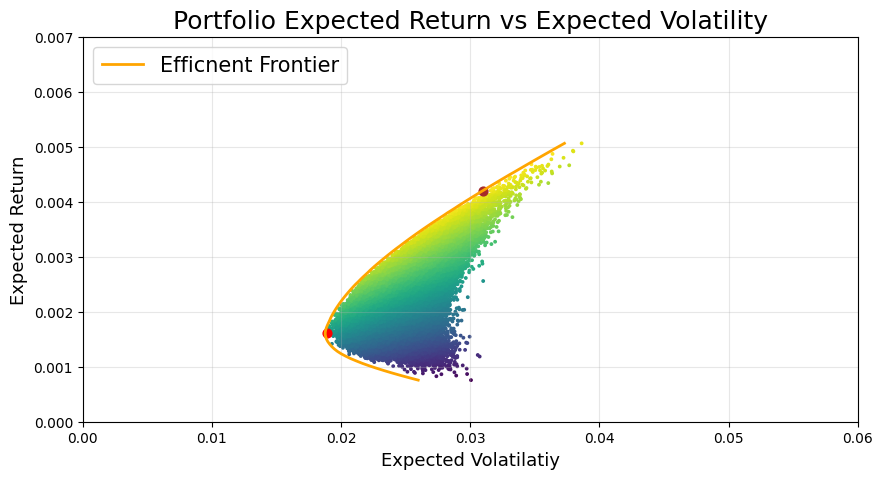

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(portfolio_vol, portfolio_ret, s=3, c=sharpe_ratio)

ax.scatter(portfolio_vol[min_idx], portfolio_ret[min_idx], c='r', s=40)
ax.scatter(portfolio_vol[max_idx], portfolio_ret[max_idx], c='brown', s=40)

ax.plot(opt_vol, rets, c='orange', linewidth=2, label='Efficnent Frontier')
# ax.text(sigma[min_idx]+0.0006, mu[min_idx]-0.000004, \
#          'Min Vol Portfolio', fontsize=12)
# ax.text(sigma[max_idx]-0.0003, mu[max_idx]+0.0002, \
#          'Max SR Portfolio', fontsize=12)

ax.set_title('Portfolio Expected Return vs Expected Volatility', fontsize=18)
ax.set_xlabel('Expected Volatilatiy', fontsize=13)
ax.set_ylabel('Expected Return', fontsize=13)
ax.set_xlim(0.0, 0.06)
ax.set_ylim(0.0, 0.007)
ax.legend(loc='upper left', fontsize=15)
ax.grid(alpha=0.3)
plt.show()